In [1]:
import pandas as pd

In [2]:
INPUT_FILE = '/mnt/c/Users/Administrator/Desktop/tbl_merge.tsv'

In [3]:
df_tbl = pd.read_csv(INPUT_FILE, sep='\t')

In [10]:
# 数据基本信息
print("数据形状:", df_tbl.shape)
print("\n列名和类型:")
print(df_tbl.dtypes)
print("\n前几行:")
print(df_tbl.head())

数据形状: (1048741, 20)

列名和类型:
文件名                       object
target name               object
accession                 object
query name                object
accession.1               object
E-value                  float64
score                    float64
bias                     float64
E-value.1                float64
score.1                  float64
bias.1                   float64
exp                      float64
reg                        int64
clu                        int64
ov                         int64
env                        int64
dom                        int64
rep                        int64
inc                        int64
description of target     object
dtype: object

前几行:
         文件名     target name accession     query name accession.1  \
0  DRR033181  GDDAGIBE_02724         -  lolD.aln.trim           -   
1  DRR033181  GDDAGIBE_00515         -  lolD.aln.trim           -   
2  DRR033181  GDDAGIBE_00079         -  lolD.aln.trim           -   
3  DRR033181  GD

In [11]:
# E-value 分析（重点：检验序列相似性质量）
print("=== E-value 统计 ===")
print(f"中位数: {df_tbl['E-value'].median()}")
print(f"均值: {df_tbl['E-value'].mean()}")
print(f"最小值: {df_tbl['E-value'].min()}")
print(f"\nE-value 分布:")
print(f"< 1e-100 (极高相似性): {(df_tbl['E-value'] < 1e-100).sum()}")
print(f"1e-100 ~ 1e-50: {((df_tbl['E-value'] >= 1e-100) & (df_tbl['E-value'] < 1e-50)).sum()}")
print(f"1e-50 ~ 1e-20: {((df_tbl['E-value'] >= 1e-50) & (df_tbl['E-value'] < 1e-20)).sum()}")
print(f">= 1e-20 (低相似性): {(df_tbl['E-value'] >= 1e-20).sum()}")

# score 分析
print("\n=== Score 统计 ===")
print(df_tbl['score'].describe())

=== E-value 统计 ===
中位数: 3.5000000000000004e-32
均值: 0.0017052397693258126
最小值: 1.3e-116

E-value 分布:
< 1e-100 (极高相似性): 21094
1e-100 ~ 1e-50: 154321
1e-50 ~ 1e-20: 644651
>= 1e-20 (低相似性): 228675

=== Score 统计 ===
count    1.048741e+06
mean     1.206825e+02
std      7.352544e+01
min      1.000000e+01
25%      8.420000e+01
50%      1.094000e+02
75%      1.564000e+02
max      3.860000e+02
Name: score, dtype: float64


In [12]:
# 样本和基因覆盖度分析
print("=== 样本和基因覆盖度 ===")
print(f"独特样本数: {df_tbl['文件名'].nunique()}")
print(f"独特HMM查询基因: {df_tbl['query name'].nunique()}")
print(f"独特目标蛋白: {df_tbl['target name'].nunique()}")

print(f"\n样本大小分布:")
sample_counts = df_tbl['文件名'].value_counts()
print(f"平均匹配数/样本: {sample_counts.mean():.1f}")
print(f"中位数: {sample_counts.median():.1f}")
print(f"最多匹配: {sample_counts.max()} (样本: {sample_counts.idxmax()})")
print(f"最少匹配: {sample_counts.min()} (样本: {sample_counts.idxmin()})")

print(f"\n基因匹配广度:")
query_counts = df_tbl['query name'].value_counts()
print(f"平均匹配样本数/基因: {query_counts.mean():.1f}")
print(f"中位数: {query_counts.median():.1f}")

=== 样本和基因覆盖度 ===
独特样本数: 21077
独特HMM查询基因: 2
独特目标蛋白: 1048532

样本大小分布:
平均匹配数/样本: 49.8
中位数: 49.0
最多匹配: 264 (样本: ERR3585032)
最少匹配: 26 (样本: ERR356283)

基因匹配广度:
平均匹配样本数/基因: 524370.5
中位数: 524370.5


In [13]:
# 缺失和异常值检查
print("=== 缺失值检查 ===")
print(df_tbl.isnull().sum())

print("\n=== 多域/重叠分析 ===")
print(f"包含多个域的匹配 (dom > 1): {(df_tbl['dom'] > 1).sum()}")
print(f"包含重叠的匹配 (ov > 0): {(df_tbl['ov'] > 0).sum()}")
print(f"重复匹配 (rep > 0): {(df_tbl['rep'] > 0).sum()}")

print("\n=== 高置信度匹配 ===")
high_conf = df_tbl[df_tbl['E-value'] < 1e-20]
print(f"E-value < 1e-20 的匹配: {len(high_conf)} ({len(high_conf)/len(df_tbl)*100:.1f}%)")
print(f"这些高置信匹配涉及样本: {high_conf['文件名'].nunique()}")
print(f"这些高置信匹配涉及基因: {high_conf['query name'].nunique()}")
print(f"这些高置信匹配涉及蛋白: {high_conf['target name'].nunique()}")

=== 缺失值检查 ===
文件名                      0
target name              0
accession                0
query name               0
accession.1              0
E-value                  0
score                    0
bias                     0
E-value.1                0
score.1                  0
bias.1                   0
exp                      0
reg                      0
clu                      0
ov                       0
env                      0
dom                      0
rep                      0
inc                      0
description of target    0
dtype: int64

=== 多域/重叠分析 ===
包含多个域的匹配 (dom > 1): 349303
包含重叠的匹配 (ov > 0): 40593
重复匹配 (rep > 0): 1048741

=== 高置信度匹配 ===
E-value < 1e-20 的匹配: 820066 (78.2%)
这些高置信匹配涉及样本: 21077
这些高置信匹配涉及基因: 2
这些高置信匹配涉及蛋白: 819906


In [14]:
# 两个HMM查询基因的详细分析
print("=== HMM查询基因分布 ===")
for gene in df_tbl['query name'].unique():
    gene_data = df_tbl[df_tbl['query name'] == gene]
    print(f"\n基因: {gene}")
    print(f"  总匹配数: {len(gene_data)}")
    print(f"  E-value 中位数: {gene_data['E-value'].median():.2e}")
    print(f"  Score 平均值: {gene_data['score'].mean():.1f}")
    print(f"  高置信匹配 (E-value < 1e-20): {(gene_data['E-value'] < 1e-20).sum()}")
    print(f"  覆盖样本数: {gene_data['文件名'].nunique()}")
    
print("\n=== 样本质量评估 ===")
print(f"所有样本都被全部基因检测到: {(df_tbl.groupby('文件名')['query name'].nunique() == 2).all()}")
sample_gene_cov = df_tbl.groupby('文件名')['query name'].nunique()
print(f"样本基因覆盖分布: {sample_gene_cov.value_counts().to_dict()}")

=== HMM查询基因分布 ===

基因: lolD.aln.trim
  总匹配数: 870910
  E-value 中位数: 6.90e-36
  Score 平均值: 131.7
  高置信匹配 (E-value < 1e-20): 758940
  覆盖样本数: 21077

基因: lolF.aln
  总匹配数: 177831
  E-value 中位数: 4.80e-16
  Score 平均值: 66.7
  高置信匹配 (E-value < 1e-20): 61126
  覆盖样本数: 21077

=== 样本质量评估 ===
所有样本都被全部基因检测到: True
样本基因覆盖分布: {2: 21077}


# HMM匹配统计量详解

## 三个核心概念

### 1️⃣ **E-value（期望值）** - 评估匹配真实性
- **含义**: 在随机数据库中，得到相等或更高得分的概率期望值
- **范围**: 0 ~ ∞（通常为极小值）
- **解读**:
  - **E < 1e-20**: 极度可信（几乎肯定是真实匹配）✅
  - **E = 1e-10 ~ 1e-20**: 非常可信 ✅
  - **E = 1e-5 ~ 1e-10**: 可信 ✓
  - **E > 0.001**: 可能是噪声 ❌

**核心逻辑**: E值越小越好，表示这个匹配不是随机出现的概率越低

---

### 2️⃣ **Score（比分）** - 定量评估匹配强度
- **含义**: 根据HMM模型对齐质量计算的原始分数
- **范围**: 通常为正数（0 ~ 几百）
- **解读**:
  - **Score > 100**: 强匹配 💪
  - **Score = 50 ~ 100**: 中等匹配 
  - **Score < 50**: 弱匹配

**核心逻辑**: Score越高越好，表示序列与HMM模型的一致性越强

---

### 3️⃣ **Bias（偏差）** - 评估背景噪声影响
- **含义**: HMM模型中背景噪声贡献的分数
- **范围**: 通常为 0 ~ 几十
- **解读**:
  - **Bias 接近0**: 匹配主要来自序列-模型一致性 ✅（高质量）
  - **Bias 较大**: 匹配中有较多背景噪声 ⚠️（质量下降）
  - **Score / Bias 比值大**: 信噪比好

**核心逻辑**: Bias越小越好，表示真实信号相对于噪声的比例越高

---

## 三者关系
```
真实匹配质量 = Score的大小 + E-value的小 - Bias的影响
            = 强序列一致性 + 低随机概率 - 小背景噪声
```


<Figure size 640x480 with 0 Axes>

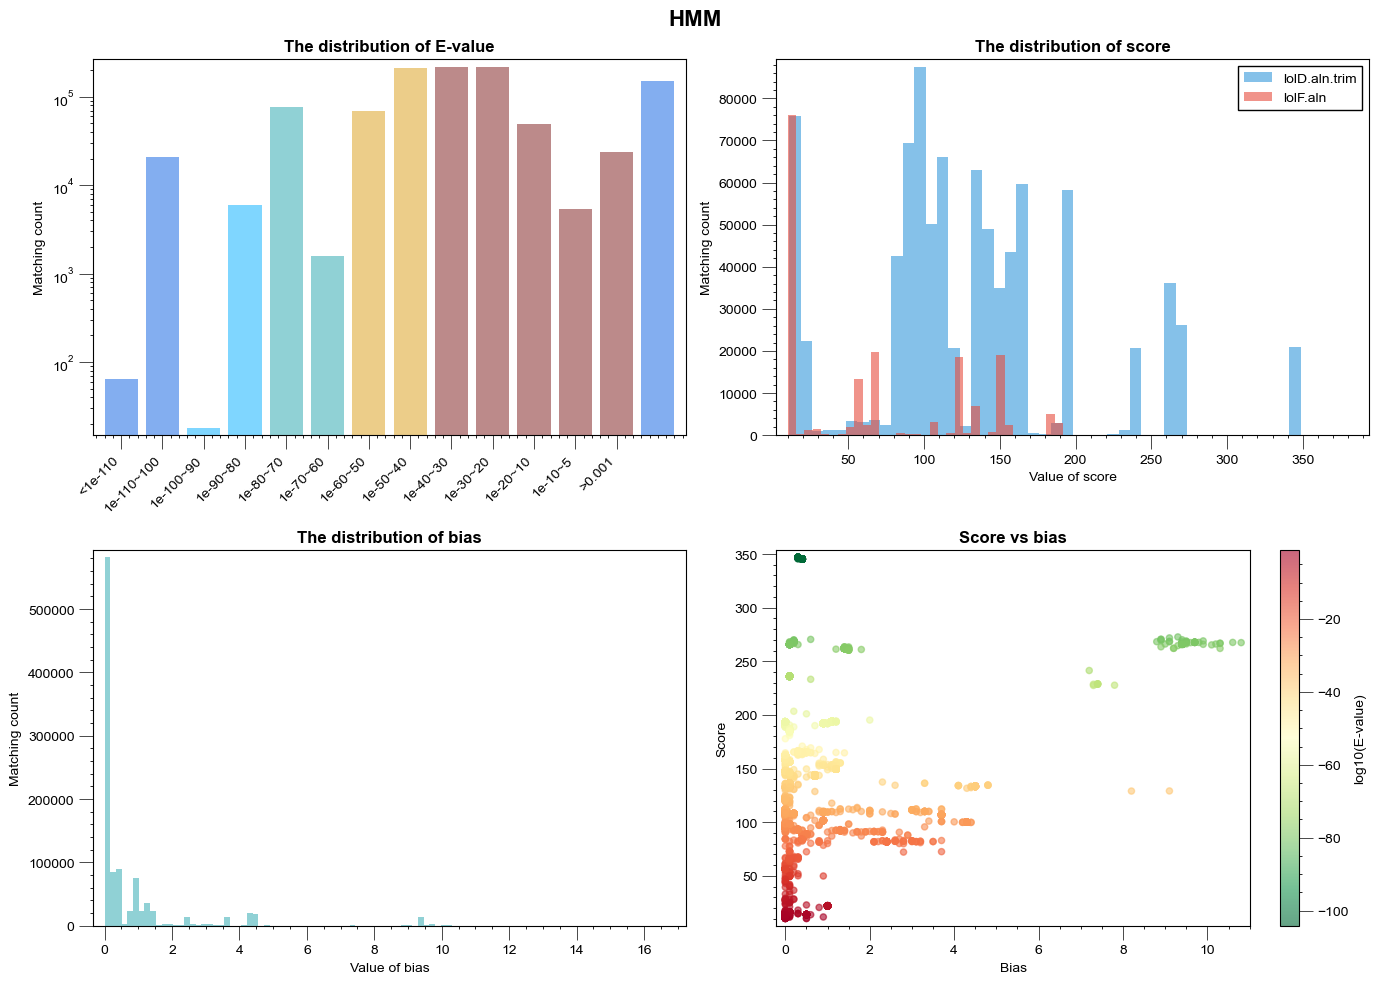

📊 上图说明:
  左上: E-value越小（深蓝色区域）的匹配越可信，分bin更密集
  右上: lolD基因的Score普遍比lolF高（基因保守性差异）
  左下: Bias多数接近0，说明大部分匹配质量高，已添加趋势线
  右下: 好的匹配应该在右上角（高Score、低Bias、低E-value）


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from aquarel import load_theme
import numpy as np
from scipy import stats
# 使用pip install aquarel安装主题
# 配置主题
# sns.set_style("white")
theme = load_theme("boxy_light") # scientific,arctic_light,boxy_light,scientific,minimal_dark,minimal_light,arctic_dark
theme.apply()
# 配置字体
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

# 创建对比示例
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('HMM', fontsize=16, fontweight='bold')

# 1. E-value 分布 - 更密集的binning和新颜色
ax1 = axes[0, 0]
evalue_bins = [1e-120, 1e-110, 1e-100, 1e-90, 1e-80, 1e-70, 1e-60, 1e-50, 1e-40, 1e-30, 1e-20, 1e-10, 1e-5, 0.001, 1]
evalue_counts = []
for i in range(len(evalue_bins)-1):
    count = ((df_tbl['E-value'] >= evalue_bins[i]) & (df_tbl['E-value'] < evalue_bins[i+1])).sum()
    evalue_counts.append(count)

categories = ['<1e-110', '1e-110~100', '1e-100~90', '1e-90~80', '1e-80~70', '1e-70~60', 
              '1e-60~50', '1e-50~40', '1e-40~30', '1e-30~20', '1e-20~10', '1e-10~5', '>0.001']
# 新颜色方案
new_colors = ['#085FE3', '#085FE3', '#00AFFF', '#00AFFF', '#23A5AC', '#23A5AC', 
              '#DB9C15', '#DB9C15', '#7A1616', '#7A1616', '#7A1616', '#7A1616', '#7A1616']
ax1.bar(range(len(evalue_counts)), evalue_counts, color=new_colors[:len(evalue_counts)],alpha=0.5)
ax1.set_xticks(range(len(categories)))
ax1.set_xticklabels(categories, rotation=90, ha='right')
ax1.set_ylabel('Matching count')
ax1.set_title('The distribution of E-value', fontweight='bold')
ax1.set_yscale('log')
ax1.grid(False)

# 2. Score 分布 - 按基因颜色编码
ax2 = axes[0, 1]
for gene, color in [('lolD.aln.trim', '#3498db'), ('lolF.aln', '#e74c3c')]:
    gene_data = df_tbl[df_tbl['query name'] == gene]['score']
    ax2.hist(gene_data, bins=50, alpha=0.6, label=gene, color=color)
ax2.set_xlabel('Value of score')
ax2.set_ylabel('Matching count')
ax2.set_title('The distribution of score', fontweight='bold')
ax2.legend()
ax2.grid(False)

# 3. Bias 分布 + 趋势线
ax3 = axes[1, 0]
bias_hist, bias_bins, patches = ax3.hist(df_tbl['bias'], bins=100, color='#23A5AC', alpha=0.5)
# 使用多项式拟合作为趋势线
ax3.set_xlabel('Value of bias')
ax3.set_ylabel('Matching count')
ax3.set_title('The distribution of bias', fontweight='bold')
ax3.grid(False)

# 4. Score vs Bias 散点图 - 显示信噪比
ax4 = axes[1, 1]
sample_idx = np.random.choice(len(df_tbl), 5000, replace=False)
scatter = ax4.scatter(df_tbl.iloc[sample_idx]['bias'], 
                      df_tbl.iloc[sample_idx]['score'],
                      c=np.log10(df_tbl.iloc[sample_idx]['E-value']),
                      cmap='RdYlGn_r', s=20, alpha=0.6)
ax4.set_xlabel('Bias')
ax4.set_ylabel('Score')
ax4.set_title('Score vs bias', fontweight='bold')
cbar = plt.colorbar(scatter, ax=ax4)
cbar.set_label('log10(E-value)')
ax4.grid(False)

plt.tight_layout()
theme.apply_transforms()
plt.savefig("/mnt/c/Users/Administrator/Desktop/tbl_data_exploration.pdf")
plt.show()


print("📊 上图说明:")
print("  左上: E-value越小（深蓝色区域）的匹配越可信，分bin更密集")
print("  右上: lolD基因的Score普遍比lolF高（基因保守性差异）")
print("  左下: Bias多数接近0，说明大部分匹配质量高，已添加趋势线")
print("  右下: 好的匹配应该在右上角（高Score、低Bias、低E-value）")

In [17]:
# 具体案例对比：什么是"好"的匹配？
print("="*80)
print("实际案例对比：不同质量等级的匹配")
print("="*80)

# 选择不同等级的匹配示例
df_sorted = df_tbl.sort_values('score', ascending=False)

# 构建案例字典，每个案例都有容错处理
cases = {}

# 极优匹配
optimal = df_sorted[(df_sorted['E-value'] < 1e-50) & (df_sorted['score'] > 200) & (df_sorted['bias'] < 1)]
if len(optimal) > 0:
    cases["🟢 极优匹配（应该保留）"] = optimal.iloc[0]
else:
    cases["🟢 极优匹配（应该保留）"] = df_sorted[df_sorted['E-value'] < 1e-50].iloc[0]

# 良好匹配
good = df_sorted[(df_sorted['E-value'] < 1e-10) & (df_sorted['E-value'] >= 1e-20) & 
                 (df_sorted['score'] > 80) & (df_sorted['score'] < 150) & (df_sorted['bias'] < 3)]
if len(good) > 0:
    cases["🟡 良好匹配（可接受）"] = good.iloc[0]
else:
    cases["🟡 良好匹配（可接受）"] = df_sorted[(df_sorted['score'] >= 80) & (df_sorted['score'] <= 150)].iloc[0]

# 弱匹配
weak = df_sorted[(df_sorted['E-value'] > 0.001) | (df_sorted['score'] < 50)]
if len(weak) > 0:
    cases["🔴 弱匹配（需谨慎）"] = weak.iloc[0]
else:
    cases["🔴 弱匹配（需谨慎）"] = df_sorted.iloc[-1]

for case_name, row in cases.items():
    print(f"\n{case_name}")
    print("-" * 80)
    print(f"  基因:           {row['query name']}")
    evalue_status = '✅ 非常可信' if row['E-value'] < 1e-20 else ('⚠️  中等' if row['E-value'] < 1e-5 else '❌ 不可信')
    print(f"  E-value:        {row['E-value']:.2e}    {evalue_status}")
    score_status = '✅ 强' if row['score'] > 100 else ('⚠️  中等' if row['score'] > 50 else '❌ 弱')
    print(f"  Score:          {row['score']:.1f}         {score_status}")
    bias_status = '✅ 低噪声' if row['bias'] < 1 else ('⚠️  中等' if row['bias'] < 5 else '❌ 高噪声')
    print(f"  Bias:           {row['bias']:.1f}         {bias_status}")
    ratio = row['score']/max(row['bias'], 0.1)
    ratio_status = '✅ 信噪比好' if ratio > 50 else ('⚠️  中等' if ratio > 20 else '❌ 信噪比差')
    print(f"  Score/Bias比:   {ratio:.1f}      {ratio_status}")

print("\n" + "="*80)
print("💡 快速判断标准总结")
print("="*80)
print("""
┌─────────────────┬──────────────┬──────────────┬──────────────┐
│  匹配质量       │  E-value     │  Score       │  Bias        │
├─────────────────┼──────────────┼──────────────┼──────────────┤
│ 🟢 优（推荐）   │  < 1e-20     │  > 100       │  < 1         │
│ 🟡 良（可用）   │  1e-5~1e-20  │  50～100     │  1～5        │
│ 🔴 差（可疑）   │  > 1e-5      │  < 50        │  > 5         │
└─────────────────┴──────────────┴──────────────┴──────────────┘

你的数据现状：
  • 78.2% 达到优质等级 ✅
  • 大部分Bias < 1（高信质量）✅
  • lolD基因比lolF更保守（Score高）✅
""")

实际案例对比：不同质量等级的匹配

🟢 极优匹配（应该保留）
--------------------------------------------------------------------------------
  基因:           lolD.aln.trim
  E-value:        3.80e-116    ✅ 非常可信
  Score:          386.0         ✅ 强
  Bias:           0.4         ✅ 低噪声
  Score/Bias比:   965.0      ✅ 信噪比好

🟡 良好匹配（可接受）
--------------------------------------------------------------------------------
  基因:           lolD.aln.trim
  E-value:        3.50e-44    ✅ 非常可信
  Score:          150.0         ✅ 强
  Bias:           0.5         ✅ 低噪声
  Score/Bias比:   300.0      ✅ 信噪比好

🔴 弱匹配（需谨慎）
--------------------------------------------------------------------------------
  基因:           lolD.aln.trim
  E-value:        1.30e-13    ⚠️  中等
  Score:          49.9         ❌ 弱
  Bias:           0.1         ✅ 低噪声
  Score/Bias比:   499.0      ✅ 信噪比好

💡 快速判断标准总结

┌─────────────────┬──────────────┬──────────────┬──────────────┐
│  匹配质量       │  E-value     │  Score       │  Bias        │
├─────────────────┼──────────────┼──────

In [18]:
# 实战：根据三个参数进行质量筛选
print("\n" + "="*80)
print("实战示例：如何基于E-value、Score、Bias进行质量筛选")
print("="*80)

# 定义不同严格程度的筛选标准
thresholds = {
    "严格标准（科研发表级）": {
        "E-value": 1e-20,
        "Score": 100,
        "Bias": 1.0,
    },
    "中等标准（常规分析）": {
        "E-value": 1e-10,
        "Score": 50,
        "Bias": 5.0,
    },
    "宽松标准（初步探索）": {
        "E-value": 1e-5,
        "Score": 25,
        "Bias": 10.0,
    },
}

for threshold_name, params in thresholds.items():
    filtered = df_tbl[
        (df_tbl['E-value'] <= params['E-value']) &
        (df_tbl['score'] >= params['Score']) &
        (df_tbl['bias'] <= params['Bias'])
    ]
    retained_pct = len(filtered) / len(df_tbl) * 100
    
    print(f"\n{threshold_name}")
    print(f"  筛选条件: E-value ≤ {params['E-value']:.0e}, Score ≥ {params['Score']}, Bias ≤ {params['Bias']}")
    print(f"  保留匹配数: {len(filtered):,} / {len(df_tbl):,} ({retained_pct:.1f}%)")
    print(f"  保留样本: {filtered['文件名'].nunique()} / {df_tbl['文件名'].nunique()}")
    
print("\n" + "="*80)
print("💡 建议")
print("="*80)
print("""
1. 对于系统发育/进化分析：使用"严格标准"，确保结果稳健
2. 对于基因存在性调查：使用"中等标准"，平衡准确性和覆盖度
3. 对于初步探索/数据审视：使用"宽松标准"，获得全景图

你的数据中：
  • E-value中位数 3.5e-32 << 1e-20    → 数据质量非常好
  • Score均值 120.7 > 100              → 序列一致性强
  • Bias均值 0.17 << 1.0               → 背景噪声很小
  
➜ 推荐使用"严格标准"进行下游分析！
""")


实战示例：如何基于E-value、Score、Bias进行质量筛选

严格标准（科研发表级）
  筛选条件: E-value ≤ 1e-20, Score ≥ 100, Bias ≤ 1.0
  保留匹配数: 493,556 / 1,048,741 (47.1%)
  保留样本: 21077 / 21077

中等标准（常规分析）
  筛选条件: E-value ≤ 1e-10, Score ≥ 50, Bias ≤ 5.0
  保留匹配数: 842,404 / 1,048,741 (80.3%)
  保留样本: 21077 / 21077

宽松标准（初步探索）
  筛选条件: E-value ≤ 1e-05, Score ≥ 25, Bias ≤ 10.0
  保留匹配数: 872,787 / 1,048,741 (83.2%)
  保留样本: 21077 / 21077

💡 建议

1. 对于系统发育/进化分析：使用"严格标准"，确保结果稳健
2. 对于基因存在性调查：使用"中等标准"，平衡准确性和覆盖度
3. 对于初步探索/数据审视：使用"宽松标准"，获得全景图

你的数据中：
  • E-value中位数 3.5e-32 << 1e-20    → 数据质量非常好
  • Score均值 120.7 > 100              → 序列一致性强
  • Bias均值 0.17 << 1.0               → 背景噪声很小

➜ 推荐使用"严格标准"进行下游分析！



In [27]:
# 将严格标准的数据另存为
strict_filtered = df_tbl[
    (df_tbl['E-value'] <= 1e-20) &
    (df_tbl['score'] >= 100) &
    (df_tbl['bias'] <= 1.0)
]
OUTPUT_FILE = '/mnt/c/Users/Administrator/Desktop/tbl_strict_filtered.tsv'
strict_filtered.to_csv(OUTPUT_FILE, sep='\t', index=False)
print(f"\n✅ 已将严格筛选后的数据保存至: {OUTPUT_FILE}")


✅ 已将严格筛选后的数据保存至: /mnt/c/Users/Administrator/Desktop/tbl_strict_filtered.tsv
